# PSO y Evolución Diferencial V.S Algoritmo Genético

- Autor: <span style="color:red">Rodrigo S. Cortez-Madrigal</span>
- web: [https://roicort.github.io](https://roicort.github.io)
- github: [https://github.com/roicort/MetaZoo](https://github.com/roicort/MetaZoo)
- docs: [https://roicort.github.io/MetaZoo/](https://roicort.github.io/MetaZoo/)

In [1]:
import time
import numpy as np
import pandas as pd
from rich.console import Console
from rich.table import Table
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from metazoo.bio.darwin import ParticleSwarmOptimizer
from metazoo.bio.evolutionary import DifferentialEvolution
from metazoo.bio.evolutionary import GeneticAlgorithm
from metazoo.bio.evolutionary.operators import crossover, mutation, selection
from metazoo.gym.mono import Function
from metazoo.gym.combinatorial import TSP, NQueens
from metazoo.bio.utils import encoding

pio.renderers.default = "png" # Or "jupyterlab"

## Parametricos

In [2]:
def plot(fitness_function, bounds, dim=1, num_points=100, population=None, mode='surface', colorscale='Viridis', labels=None) -> go.Figure:
    metadata = getattr(fitness_function, 'metadata', {}).get(fitness_function.__name__, None)
    title = f'${{\\text{{{fitness_function.__name__.capitalize()} function }}:{metadata["formula"]}}}$' if metadata else f'{fitness_function.__name__.capitalize()} function'
    subtitle = f'Bounds: {bounds}' if bounds else ""
    func = fitness_function.__call__
    colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

    if dim == 1:
        if isinstance(bounds[0], (tuple, list)):
            x_bounds = bounds[0]
        else:
            x_bounds = bounds
        x = np.linspace(x_bounds[0], x_bounds[1], num_points)
        y = np.array([func(np.array([xi])) for xi in x])
        fig = go.Figure()
        fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name='Function'))
        if population is not None:
            if labels is None and population.shape[0] == 3:
                labels = ['PSO', 'DE', 'GA']
            for i, ind in enumerate(population):
                label = labels[i] if labels and i < len(labels) else 'Individual'
                color = colors[i % len(colors)]
                pop_x = ind[0]
                pop_y = func(np.array([pop_x]))
                fig.add_trace(go.Scatter(x=[pop_x], y=[pop_y], mode='markers', name=label, marker=dict(color=color, size=10)))
        fig.update_layout(title=title, xaxis_title='x', yaxis_title='f(x)')
    elif dim == 2:
        if isinstance(bounds[0], (tuple, list)) and isinstance(bounds[1], (tuple, list)):
            x_bounds = bounds[0]
            y_bounds = bounds[1]
        else:
            x_bounds = y_bounds = bounds
        x = np.linspace(x_bounds[0], x_bounds[1], num_points)
        y = np.linspace(y_bounds[0], y_bounds[1], num_points)
        X, Y = np.meshgrid(x, y)
        Z = np.array([func(np.array([xi, yi])) for xi, yi in zip(np.ravel(X), np.ravel(Y))])
        Z = Z.reshape(X.shape)
        fig = go.Figure()
        if mode == 'surface':
            fig.add_trace(go.Surface(z=Z, x=X, y=Y, colorscale=colorscale, opacity=0.7, name='Function'))
            if population is not None:
                if labels is None and population.shape[0] == 3:
                    labels = ['PSO', 'DE', 'GA']
                for i, ind in enumerate(population):
                    label = labels[i] if labels and i < len(labels) else 'Individual'
                    color = colors[i % len(colors)]
                    pop_x = ind[0]
                    pop_y = ind[1]
                    pop_z = func(np.array([pop_x, pop_y]))
                    fig.add_trace(go.Scatter3d(x=[pop_x], y=[pop_y], z=[pop_z], mode='markers', name=label, marker=dict(color=color, size=6)))
            fig.update_layout(title=title, scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='f(x, y)'))
        elif mode == 'contour':
            fig.add_trace(go.Contour(z=Z, x=x, y=y, colorscale=colorscale, name='Function'))
            if population is not None:
                if labels is None and population.shape[0] == 3:
                    labels = ['PSO', 'DE', 'GA']
                for i, ind in enumerate(population):
                    label = labels[i] if labels and i < len(labels) else 'Individual'
                    color = colors[i % len(colors)]
                    pop_x = ind[0]
                    pop_y = ind[1]
                    fig.add_trace(go.Scatter(x=[pop_x], y=[pop_y], mode='markers', name=label, marker=dict(color=color, size=10)))
            fig.update_layout(title=title, xaxis_title='x', yaxis_title='y')
        else:
            raise ValueError("Mode should be 'surface' or 'contour'.")
    else:
        raise ValueError('Only 1D or 2D functions are supported for plotting.')
    
    fig.update_layout(
        title={'text': title, 'x':0.5},
        annotations=[dict(text=subtitle, x=0.5, y=-0.15, showarrow=False, xref="paper", yref="paper", xanchor='center', yanchor='top')],
        legend=dict(orientation='h', x=0.5, xanchor='center', y=-0.2),
        showlegend=True
    )
    return fig

In [3]:
targets = ['Sphere', 'Bukin', 'Himmelblau', 'EggHolder', 'Easom']

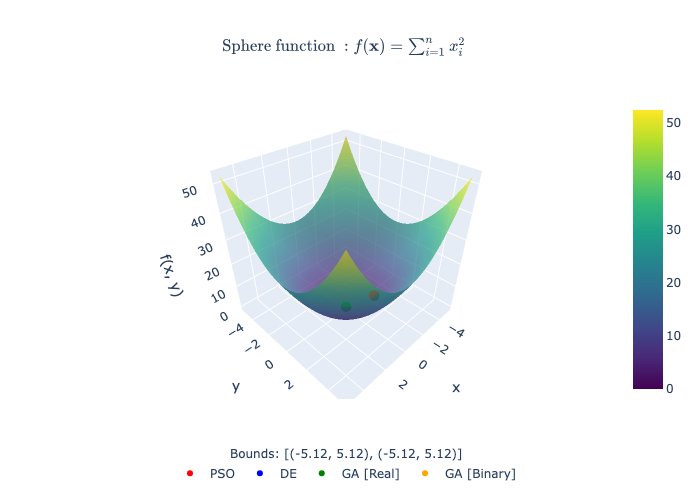

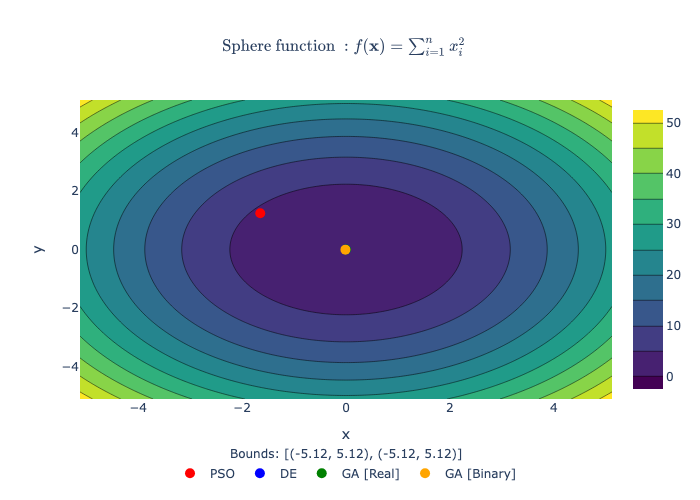

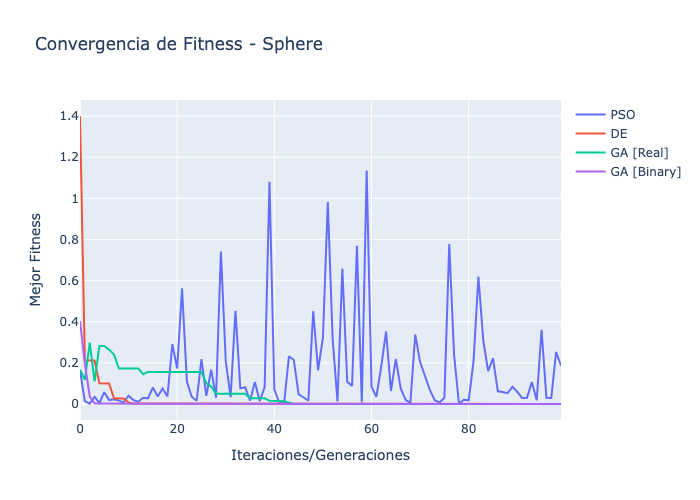

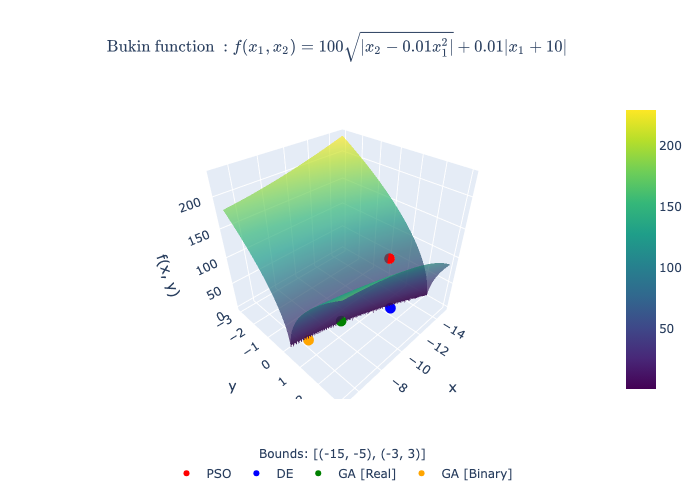

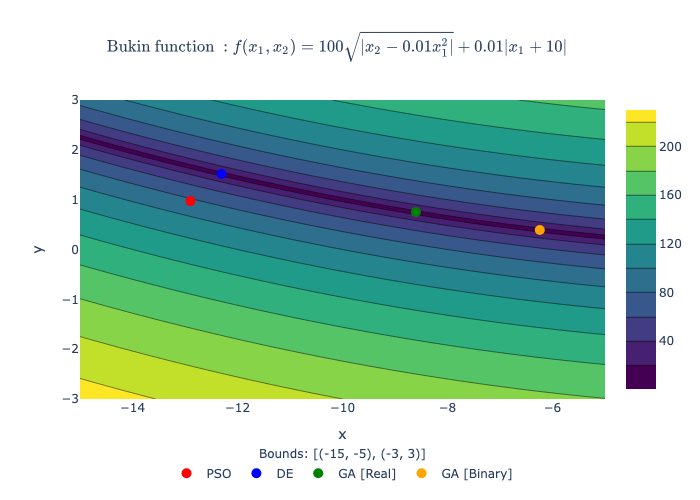

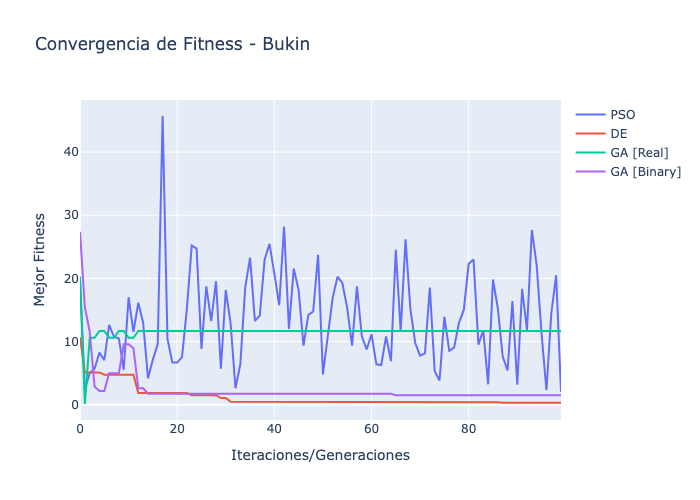

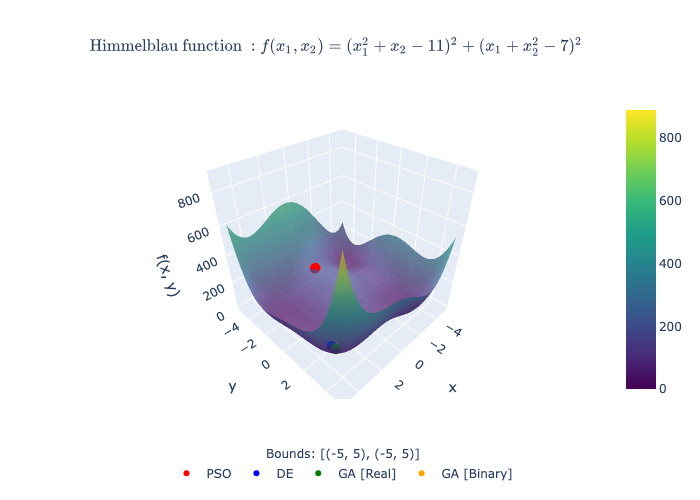

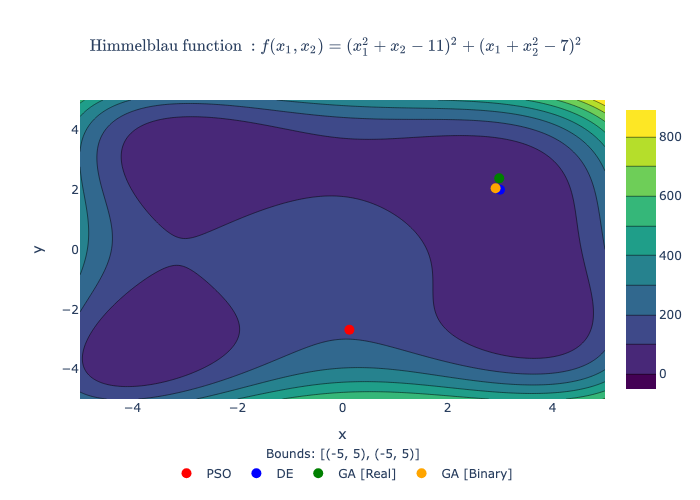

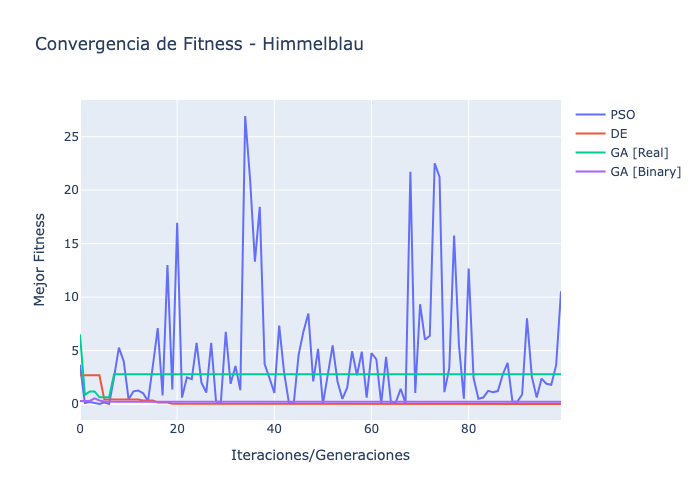

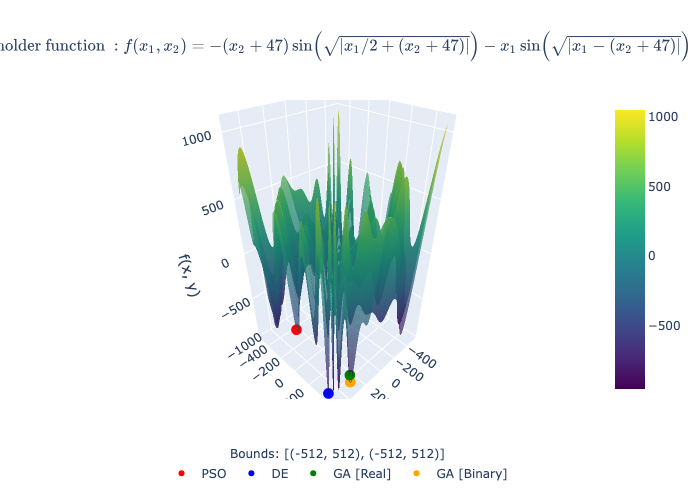

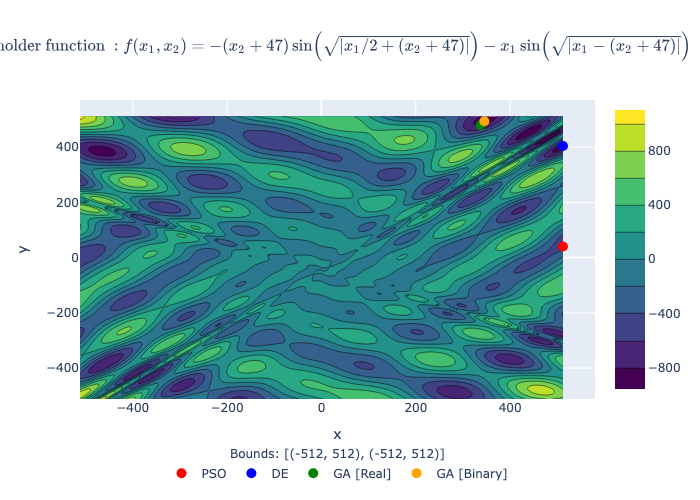

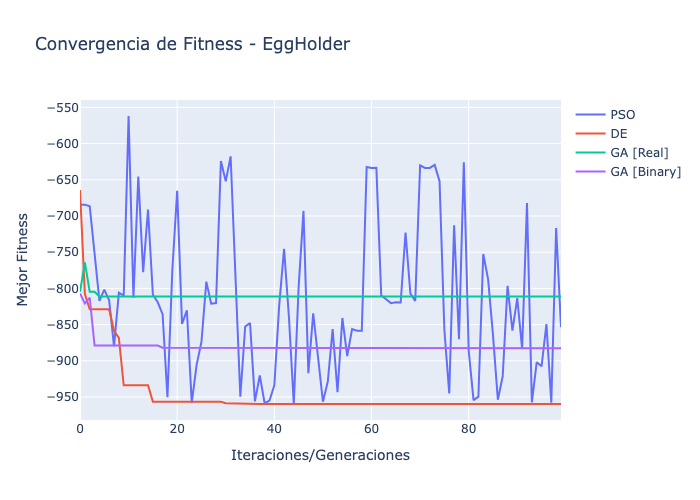

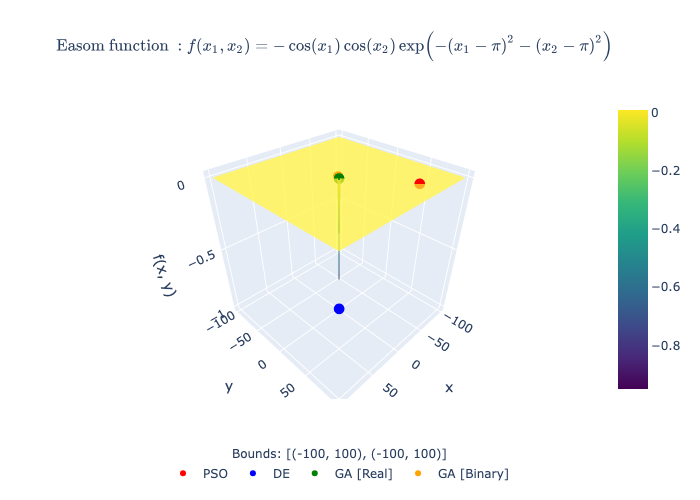

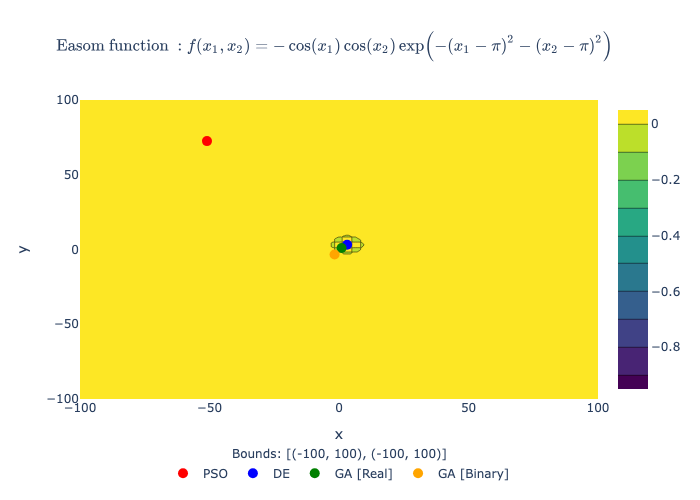

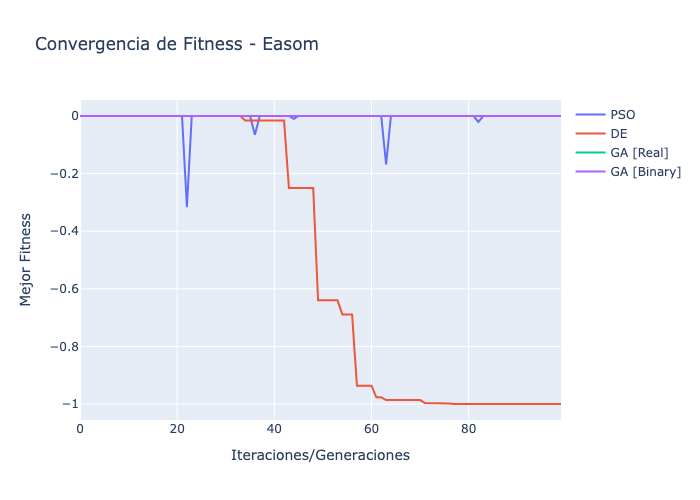

                             Resultados de Algoritmos Evolutivos                             
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Función    ┃ Algoritmo   ┃ Mejor Individuo                   ┃ Mejor Fitness ┃ Tiempo (s) ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ Sphere     │ PSO         │ [-1.65060322  1.24021557]         │ 0.186         │ 0.0606     │
│ Sphere     │ DE          │ [-3.04835017e-09 -5.65848739e-09] │ 4.131e-17     │ 0.1797     │
│ Sphere     │ GA [Real]   │ [0. 0.]                           │ 0             │ 0.0883     │
│ Sphere     │ GA [Binary] │ [-0.01093817 -0.00531282]         │ 0.0001479     │ 0.1361     │
│ Bukin      │ PSO         │ [-12.8956421    0.97077281]       │ 2.044         │ 0.0614     │
│ Bukin      │ DE          │ [-12.30508747   1.51414406]       │ 0.3008        │ 0.1963     │
│ Bukin      │ GA [Real]   │ [-8.60151284  0.75345648]         │ 11.67         │ 0.0955     │
│ Bukin      │ GA [Binary] │ [-6.24214124  0.38985534]         │ 1.494         │ 0.1222     │
│ Himmelblau │ PSO         │ [ 0.13120575 -2.68113725]         │ 10.54         │ 0.0508     │
│ Himmelblau │ DE          │ [3.00000113 2.00000672]           │ 9.667e-10     │ 0.1670     │
│ Himmelblau │ GA [Real]   │ [2.98532564 2.37888016]           │ 2.789         │ 0.0866     │
│ Himmelblau │ GA [Binary] │ [2.91613258 2.04754929]           │ 0.2131        │ 0.1199     │
│ EggHolder  │ PSO         │ [512.          40.04134675]       │ -853.5        │ 0.0730     │
│ EggHolder  │ DE          │ [512.         404.23180515]       │ -959.6        │ 0.2002     │
│ EggHolder  │ GA [Real]   │ [336.96643518 479.60054802]       │ -811.2        │ 0.0983     │
│ EggHolder  │ GA [Binary] │ [345.20687218 493.99217033]       │ -882.6        │ 0.1376     │
│ Easom      │ PSO         │ [-50.97484543  72.50948149]       │ -3.882e-156   │ 0.0648     │
│ Easom      │ DE          │ [3.14156262 3.14159792]           │ -1            │ 0.1956     │
│ Easom      │ GA [Real]   │ [1. 1.]                           │ -3.031e-05    │ 0.0959     │
│ Easom      │ GA [Binary] │ [-1.70937237 -3.32070664]         │ -5.982e-30    │ 0.1606     │
└────────────┴─────────────┴───────────────────────────────────┴───────────────┴────────────┘

In [ ]:
console = Console()

table = Table(title="Resultados de Algoritmos Evolutivos")
table.add_column("Función", style="bold cyan")
table.add_column("Algoritmo", style="bold magenta")
table.add_column("Mejor Individuo", style="white")
table.add_column("Mejor Fitness", style="green")
table.add_column("Tiempo (s)", style="yellow")

for target in targets:
    fitness_function = Function(target, reverse=False)
    encoder = encoding.Real(bounds=fitness_function.bounds)

    # PSO
    pso = ParticleSwarmOptimizer(
        fitness_function,
        encoder=encoder,
        population_size=90,
        inertia=0.7,
        cognitive=1.5,
        social=1.5,
        minimize=True,
    )
    start = time.time()
    pso.run(iterations=100, verbose=False)
    pso_time = time.time() - start

    # DE
    de = DifferentialEvolution(
        fitness_function,
        encoder=encoder,
        population_size=90,
        F=0.8,
        CR=0.9,
        minimize=True,
    )
    start = time.time()
    de.run(generations=100, verbose=False)
    de_time = time.time() - start

    # GA [Real]
    ga = GeneticAlgorithm(
        fitness_function,
        encoder=encoder,
        crossover_function=crossover.onepoint,
        mutation_function=mutation.gaussian,
        selection_function=selection.tournament,
        population_size=90,
        mutation_rate=0.01,
        crossover_rate=0.7,
        elitism=0.1,
        minimize=True,
    )
    start = time.time()
    ga.run(generations=100, verbose=False)
    ga_time = time.time() - start

    # GA [Binary]

    gab = GeneticAlgorithm(
        fitness_function,
        encoder=encoding.Binary(precision=3, bounds=fitness_function.bounds),
        crossover_function=crossover.onepoint,
        mutation_function=mutation.flip_bit,
        selection_function=selection.tournament,
        population_size=90,
        mutation_rate=0.01,
        crossover_rate=0.7,
        elitism=0.1,
        minimize=True,
    )
    start = time.time()
    gab.run(generations=100, verbose=False)
    gab_time = time.time() - start

    # Agrega resultados a la tabla
    table.add_row(target, "PSO", str(pso.global_best_position), f"{pso.best_fitness:.4g}", f"{pso_time:.4f}")
    table.add_row(target, "DE", str(de.best_individual), f"{de.best_fitness:.4g}", f"{de_time:.4f}")
    table.add_row(target, "GA [Real]", str(ga.best_individual), f"{ga.best_fitness:.4g}", f"{ga_time:.4f}")
    table.add_row(target, "GA [Binary]", str(gab.best_individual), f"{gab.best_fitness:.4g}", f"{gab_time:.4f}")

    
    gabest = ga.best_individual
    gabbest = gab.best_individual
    debest = de.best_individual
    psobest = pso.global_best_position

    labels = ['PSO', 'DE', 'GA [Real]', 'GA [Binary]']
    fig1 = plot(fitness_function, fitness_function.bounds, dim=2, num_points=300, mode='surface', population=np.array([psobest, debest, gabest, gabbest]), labels=labels)
    fig2 = plot(fitness_function, fitness_function.bounds, dim=2, num_points=300, mode='contour', population=np.array([psobest, debest, gabest, gabbest]), labels=labels)

    fig1.show()
    fig2.show()

    # Plot fitness convergence
    fig = go.Figure()
    fig.add_trace(go.Scatter(y=pso.best_history, mode='lines', name='PSO'))
    fig.add_trace(go.Scatter(y=de.best_history, mode='lines', name='DE'))
    fig.add_trace(go.Scatter(y=ga.best_history, mode='lines', name='GA [Real]'))
    fig.add_trace(go.Scatter(y=gab.best_history, mode='lines', name='GA [Binary]'))
    fig.update_layout(title=f'Convergencia de Fitness - {target}',
                      xaxis_title='Iteraciones/Generaciones',
                      yaxis_title='Mejor Fitness')
    fig.show()

console.print(table)

Comparando el desempeño de los algoritmos de Optimización por Enjambre de Partículas (PSO) y Evolución Diferencial (DE) contra un Algoritmo Genético (GA) en funciones de optimización continua (tanto en su versión real como binaria) para un conjunto de funciones objetivo, observamos lo siguiente:

- PSO y DE tienden a converger más rápidamente que GA en la mayoría de las funciones objetivo.

- GA en su versión binaria muestra un desempeño competitivo, pero generalmente es superado por PSO y DE en términos de velocidad de convergencia y calidad de la solución final.

- La elección del codificador (real vs binario) en GA afecta significativamente su desempeño, siendo la versión real generalmente más efectiva para funciones continuas.


## Combinatorios

### TSP

In [5]:
tsp = TSP.Berlin52()
encoder = encoding.Permutation(permutation_size=tsp.dimension)

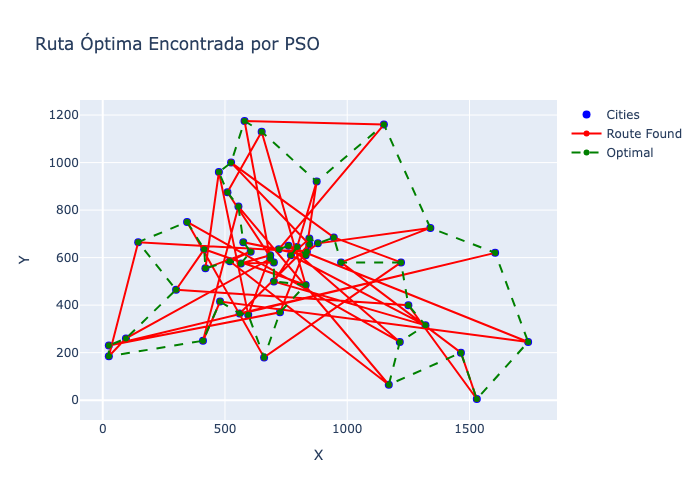

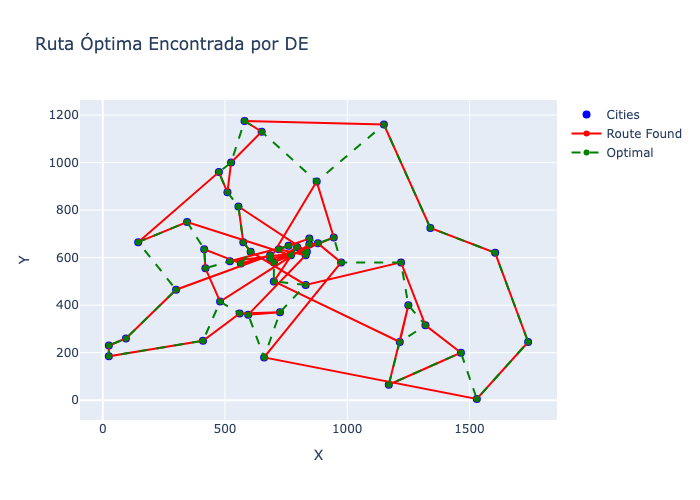

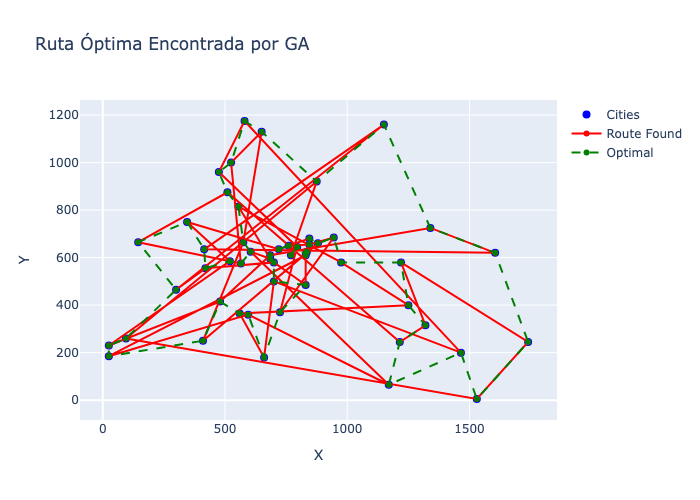

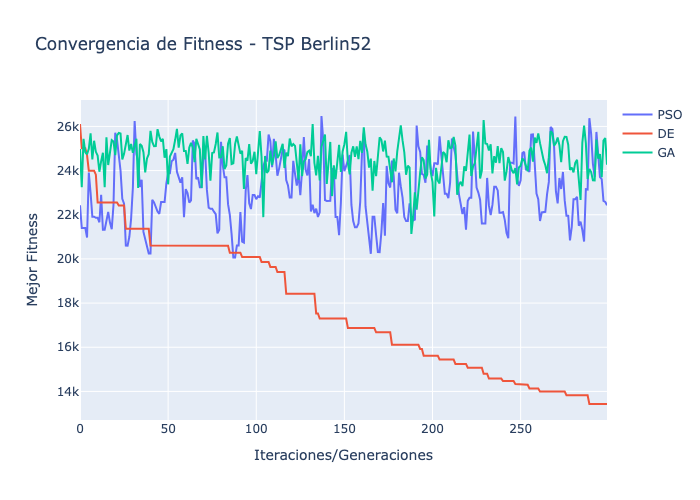

               Resultados de Algoritmos Evolutivos - TSP Berlin52               
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Algoritmo ┃ Mejor Fitness      ┃ Optimo ┃ Diferencia con Óptimo ┃ Tiempo (s) ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ PSO       │ 22433.81903708857  │ 7542.0 │ 14891.819037088571    │ 5.7024     │
│ DE        │ 13430.469697734032 │ 7542.0 │ 5888.469697734032     │ 8.1646     │
│ GA        │ 24266.81302798284  │ 7542.0 │ 16724.81302798284     │ 1.7284     │
└───────────┴────────────────────┴────────┴───────────────────────┴────────────┘

In [ ]:
console = Console()

table = Table(title="Resultados de Algoritmos Evolutivos - TSP Berlin52")

table.add_column("Algoritmo", style="bold magenta")
table.add_column("Mejor Fitness", style="green")
table.add_column("Optimo", style="green")
table.add_column("Diferencia con Óptimo", style="red")
table.add_column("Tiempo (s)", style="yellow")

# PSO
pso = ParticleSwarmOptimizer(
    tsp,
    encoder=encoder,
    population_size=200,
    inertia=0.7,
    cognitive=1.0,
    social=1.5,
    minimize=True,
)
start = time.time()
pso.run(iterations=300, verbose=False)
pso_time = time.time() - start

# DE

de = DifferentialEvolution(
    tsp,
    encoder=encoder,
    population_size=200,
    F=0.8,
    CR=0.9,
    minimize=True,
)
start = time.time()
de.run(generations=300, verbose=False)
de_time = time.time() - start

# GA

ga = GeneticAlgorithm(
    tsp,
    encoder=encoder,
    crossover_function=crossover.PMX,
    mutation_function=mutation.swap,
    selection_function=selection.tournament,
    population_size=200,
    mutation_rate=0.01,
    crossover_rate=0.7,
    elitism=0.1,
    minimize=True,
)
start = time.time()
ga.run(generations=300, verbose=False)
ga_time = time.time() - start

# Agrega resultados a la tabla
table.add_row("PSO", f"{pso.best_fitness}", f"{tsp.optimal_value}", f"{pso.best_fitness - tsp.optimal_value}", f"{pso_time:.4f}")
table.add_row("DE", f"{de.best_fitness}", f"{tsp.optimal_value}", f"{de.best_fitness - tsp.optimal_value}", f"{de_time:.4f}")
table.add_row("GA", f"{ga.best_fitness}", f"{tsp.optimal_value}", f"{ga.best_fitness - tsp.optimal_value}", f"{ga_time:.4f}")

# Mostrar rutas óptimas encontradas
fig = tsp.plot(show_optimal=True, solution=pso.global_best_position)
fig.update_layout(title='Ruta Óptima Encontrada por PSO')
fig.show()
fig = tsp.plot(show_optimal=True, solution=de.best_individual)
fig.update_layout(title='Ruta Óptima Encontrada por DE')
fig.show()
fig = tsp.plot(show_optimal=True, solution=ga.best_individual)
fig.update_layout(title='Ruta Óptima Encontrada por GA')
fig.show()

# Plot fitness convergence
fig = go.Figure()
fig.add_trace(go.Scatter(y=pso.best_history, mode='lines', name='PSO'))
fig.add_trace(go.Scatter(y=de.best_history, mode='lines', name='DE'))
fig.add_trace(go.Scatter(y=ga.best_history, mode='lines', name='GA'))
fig.update_layout(title='Convergencia de Fitness - TSP Berlin52',
                  xaxis_title='Iteraciones/Generaciones',
                  yaxis_title='Mejor Fitness')
fig.show()

console.print(table)

### N-Queens

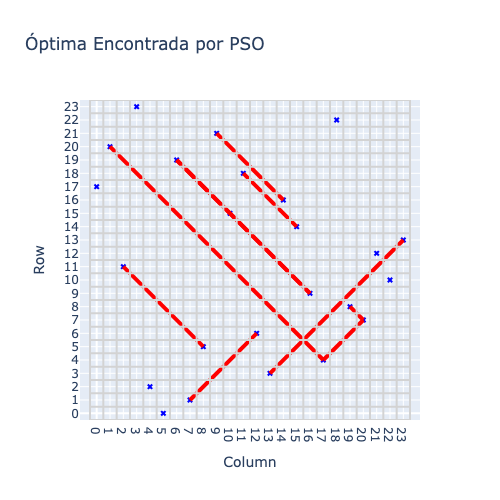

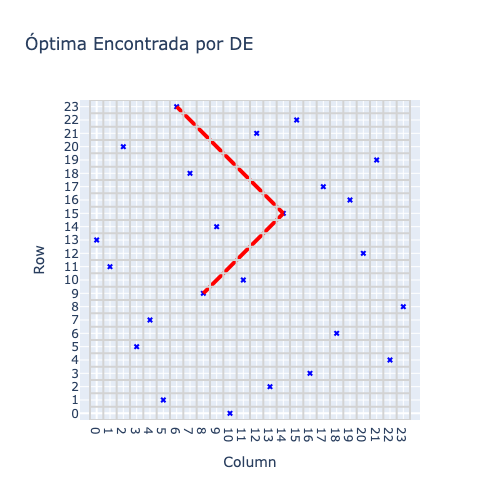

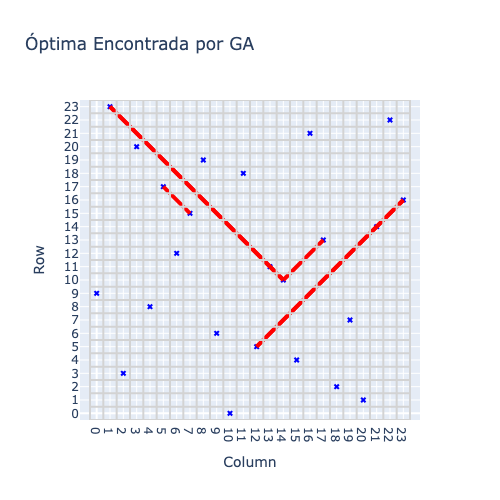

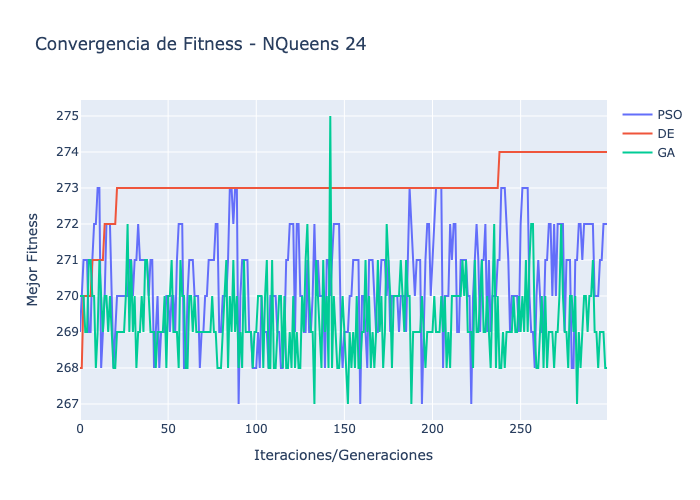

Resultados de Algoritmos Evolutivos - TSP 
                 Berlin52                 
┏━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃ Algoritmo ┃ Mejor Fitness ┃ Tiempo (s) ┃
┡━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ PSO       │ 272.0         │ 6.1005     │
│ DE        │ 274.0         │ 11.1527    │
│ GA        │ 268.0         │ 4.3987     │
└───────────┴───────────────┴────────────┘

In [ ]:
nqueens = NQueens(n=24)
encoder = encoding.Permutation(permutation_size=nqueens.n)

console = Console()

table = Table(title="Resultados de Algoritmos Evolutivos - NQueens 24")

table.add_column("Algoritmo", style="bold magenta")
table.add_column("Mejor Fitness", style="green")
table.add_column("Tiempo (s)", style="yellow")

# PSO
pso = ParticleSwarmOptimizer(
    nqueens,
    encoder=encoder,
    population_size=200,
    inertia=0.7,
    cognitive=1.0,
    social=1.5,
    minimize=False,
)
start = time.time()
pso.run(iterations=300, verbose=False)
pso_time = time.time() - start

# DE

de = DifferentialEvolution(
    nqueens,
    encoder=encoder,
    population_size=200,
    F=0.8,
    CR=0.9,
    minimize=False,
)
start = time.time()
de.run(generations=300, verbose=False)
de_time = time.time() - start

# GA

ga = GeneticAlgorithm(
    nqueens,
    encoder=encoder,
    crossover_function=crossover.PMX,
    mutation_function=mutation.swap,
    selection_function=selection.tournament,
    population_size=200,
    mutation_rate=0.01,
    crossover_rate=0.7,
    elitism=0.1,
    minimize=False,
)
start = time.time()
ga.run(generations=300, verbose=False)
ga_time = time.time() - start

# Agrega resultados a la tabla
table.add_row("PSO", f"{pso.best_fitness}", f"{pso_time:.4f}")
table.add_row("DE", f"{de.best_fitness}", f"{de_time:.4f}")
table.add_row("GA", f"{ga.best_fitness}", f"{ga_time:.4f}")

# Mostrar rutas óptimas encontradas
fig = nqueens.plot(solution=pso.global_best_position)
fig.update_layout(title='Óptima Encontrada por PSO')
fig.show()
fig = nqueens.plot(solution=de.best_individual)
fig.update_layout(title='Óptima Encontrada por DE')
fig.show()
fig = nqueens.plot(solution=ga.best_individual)
fig.update_layout(title='Óptima Encontrada por GA')
fig.show()

# Plot fitness convergence
fig = go.Figure()
fig.add_trace(go.Scatter(y=pso.best_history, mode='lines', name='PSO'))
fig.add_trace(go.Scatter(y=de.best_history, mode='lines', name='DE'))
fig.add_trace(go.Scatter(y=ga.best_history, mode='lines', name='GA'))
fig.update_layout(title='Convergencia de Fitness - NQueens 24',
                  xaxis_title='Iteraciones/Generaciones',
                  yaxis_title='Mejor Fitness')
fig.show()

console.print(table)